# ICE and PDP Plots: Global and Local Feature Effects

**Domain:** `responsible-data-science`

A trained model is a function $\hat{f}: \mathbb{R}^p \to \mathbb{R}$ that
maps $p$ input features to a prediction. For anything beyond a linear model,
that function is opaque: you cannot read "how does the prediction change as
median income increases?" off of a gradient-boosted ensemble of 300 trees
the way you can off of a linear coefficient.

**Partial Dependence Plots (PDP)** and **Individual Conditional Expectation
(ICE)** curves are two of the oldest and most widely used tools for
answering exactly that question — not by inspecting the model's internals,
but by *probing* it: repeatedly querying the trained model at systematically
varied inputs and plotting how the output responds. PDP gives you the
*average* response of the model to a feature across the whole dataset
(a global summary). ICE gives you that response *per instance*, before any
averaging (a local, instance-level view) — and, as this tutorial shows
concretely, the averaging step in PDP can silently erase exactly the
behavior (heterogeneous, opposing-sign effects; interactions) that you most
need to see.

By the end of this tutorial you will be able to:

- State and derive the Monte Carlo approximation PDP actually computes, and
  name the independence assumption baked into it.
- Show, with a small worked example, exactly how that assumption breaks
  when features are correlated — including the specific failure mode
  (extrapolation into impossible feature combinations).
- Define ICE curves formally, show algebraically that PDP is the pointwise
  mean of all ICE curves, and use *centered* ICE (c-ICE) to expose
  heterogeneous effects a PDP hides.
- Compute real PDP, ICE, and c-ICE plots — including a 2D interaction PDP —
  on a gradient-boosted model trained on the California Housing dataset
  using `sklearn.inspection`, and report the real, quantified heterogeneity
  we find in the trained model.
- Explain why ALE plots (Apley & Zhu, 2020) exist, and why "what the model
  does" (PDP) is not the same claim as "the true causal effect of a
  feature" — a distinction this tutorial connects explicitly to the
  causal/counterfactual framing used elsewhere in this repo's fairness
  material.

**Level:** Intermediate | **Prerequisites:** supervised learning basics,
comfort with expectation/conditioning notation, scikit-learn familiarity.


## 1. Theory

### 1.1 Setup and notation

Let $\hat{f}: \mathbb{R}^p \to \mathbb{R}$ be a trained model (regression or
a class-probability output for classification) over $p$ features
$X = (X_1, \dots, X_p)$. Partition the feature set into two disjoint groups:

- $X_S$ — the **feature(s) of interest** we want to plot the effect of
  (usually $|S| \in \{1, 2\}$ so the result is plottable).
- $X_C$ — the **complement**, all remaining features ($C = \{1,\dots,p\}
  \setminus S$).

So $X = (X_S, X_C)$ and $\hat f(X) = \hat f(X_S, X_C)$.

### 1.2 Partial Dependence Function (Friedman, 2001)

The **partial dependence function** of $\hat f$ on $X_S$ is defined as the
expectation of the model's output over the marginal distribution of the
complement features, with $X_S$ held fixed at a value $x_S$:

$$
f_S(x_S) \;=\; \mathbb{E}_{X_C}\!\left[\hat f(x_S, X_C)\right\ ]
\;=\; \int \hat f(x_S, x_C)\, p(x_C)\, dx_C
$$

Read this carefully: $x_S$ is a fixed constant we choose, while $X_C$ is
integrated out (averaged over) according to its **marginal** distribution
$p(x_C)$ — the distribution of the complement features *ignoring* whatever
value $X_S$ actually takes in the data. This is the crucial modeling choice
this whole tutorial is about, and Section 5 unpacks the consequences.

**The Monte Carlo approximation.** In practice we don't know $p(x_C)$
analytically — we only have $n$ observed training rows
$\{(x_S^{(i)}, x_C^{(i)})\}_{i=1}^n$. Replacing the true marginal
distribution with its empirical distribution (i.e. treating each observed
$x_C^{(i)}$ as equally likely, $\frac{1}{n}$ probability mass each) turns
the integral above into a Monte Carlo sum:

$$
\hat f_S(x_S) \;=\; \frac{1}{n} \sum_{i=1}^{n} \hat f\!\left(x_S,\, x_C^{(i)}\right)
$$

**What this is actually doing, operationally:** take every row $i$ in the
dataset, *overwrite* its $S$-features with the fixed value $x_S$ (leaving
its own, real $x_C^{(i)}$ untouched), run all $n$ of these synthetic rows
through the trained model, and average the $n$ predictions. Repeat this for
a grid of $x_S$ values and you get the PDP curve/surface. Every single
point on a PDP curve is the average of $n$ model queries.

**Core assumption.** The derivation above is only faithful to
$\mathbb{E}_{X_C}[\hat f(x_S, X_C)]$ if $X_S$ and $X_C$ are (at least
approximately) **statistically independent**. If they are not, the
empirical marginal distribution of $X_C$ used at every fixed $x_S$ is the
*same* for every $x_S$ — but the *true, conditional* distribution
$p(x_C \mid X_S = x_S)$ generally is not the same across $x_S$ when the
features are correlated. PDP evaluates the model at combinations
$(x_S, x_C^{(i)})$ that mix a chosen $x_S$ with *every* observed $x_C^{(i)}$
in the dataset — including combinations that never co-occur in reality.
Section 1.4 makes this concrete with numbers.

### 1.3 Individual Conditional Expectation (ICE) curves (Goldstein, Kapelner, Bleich, Pitkin, 2015)

PDP's average is a single summary curve. **ICE curves** are the
non-averaged version of the same underlying operation: instead of
averaging over all $n$ rows, plot the model's response to varying $x_S$
**separately, for each individual instance** $i$, holding that instance's
*own* $x_C^{(i)}$ fixed:

$$
\hat f_S^{(i)}(x_S) \;=\; \hat f\!\left(x_S,\, x_C^{(i)}\right), \qquad i = 1, \dots, n
$$

This gives $n$ curves (one per instance) instead of one curve. Because
$\hat f_S^{(i)}(x_S)$ is exactly the $i$-th term inside the PDP sum above,
the relationship between the two is immediate:

$$
\hat f_S(x_S) \;=\; \frac{1}{n}\sum_{i=1}^n \hat f_S^{(i)}(x_S)
$$

**PDP is literally the pointwise (vertical) average of every ICE curve, at
every value of $x_S$.** This is not an analogy — it is an algebraic
identity, and it is exactly what makes PDP dangerous in the presence of
heterogeneous effects: an average can look flat, monotone, or mild even
when the individual curves being averaged are wildly different, or even
have opposite slopes that cancel.

### 1.4 A worked example: correlated features and extrapolation

Take two features that are (for illustration) **perfectly correlated**:
$X_2 = X_1$, with $X_1 \sim \mathrm{Uniform}(0, 10)$. Suppose the *true*
data-generating function the model has learned is

$$
\hat f(x_1, x_2) = x_1 - x_2
$$

Because every real data point satisfies $x_2 = x_1$, the model's output on
**real data is always exactly 0** — $\hat f(x_1, x_1) = x_1 - x_1 = 0$ for
every observation, regardless of $x_1$. A perfect, honest description of
"what this model does on data that could actually occur" is: *constant,
zero, no effect of $X_1$*.

Now compute the PDP of $X_1$ using Friedman's formula. Fixing
$x_1 = x_1^\star$ and averaging over the empirical marginal of $X_2$ (which,
remember, ranges uniformly over $(0, 10)$ regardless of what $x_1^\star$ is):

$$
\hat f_1(x_1^\star) = \frac{1}{n}\sum_{i=1}^n \hat f(x_1^\star, x_2^{(i)})
= \frac{1}{n}\sum_{i=1}^n \left(x_1^\star - x_2^{(i)}\right)
= x_1^\star - \bar{x}_2 \approx x_1^\star - 5
$$

The PDP is **a straight line with slope 1**, running from about $-5$ to
$+5$ — a strong, clean, "$X_1$ has a large positive effect" story. But every
single point on that line away from $x_1^\star = 5$ was computed by
evaluating $\hat f$ at a combination $(x_1^\star, x_2^{(i)})$ with
$x_2^{(i)} \ne x_1^\star$ — a combination that is **impossible** under the
true (perfectly correlated) data-generating process. The PDP is not wrong
arithmetically; it is answering a well-defined but *fictional* question:
"what would the model predict if $X_1$ and $X_2$ could vary independently,"
when in reality they cannot. The code cell in Section 2 reproduces this
exact example numerically.

### 1.5 Centered ICE (c-ICE) and heterogeneous effects

Raw ICE curves for $n$ instances can differ in their vertical offset simply
because instances have different baseline predictions (e.g. a house that is
already expensive for other reasons will have a higher ICE curve
*everywhere*, even if its curve has the exact same shape/slope as a cheap
house's curve). This offset makes it hard to visually compare curve
**shapes** — which is usually what we actually care about (does the
feature's effect differ across instances?).

**Centered ICE (c-ICE)** removes the offset by anchoring every curve to a
common reference point, typically the leftmost grid value $x_S^{(0)}$:

$$
\tilde f_S^{(i)}(x_S) = \hat f_S^{(i)}(x_S) - \hat f_S^{(i)}(x_S^{(0)})
$$

Every c-ICE curve now starts at 0. What remains visible is exactly the
*shape* of each instance's response — and this is where PDP's averaging
failure becomes visually obvious: if half the instances have a strongly
positive c-ICE slope and half have a strongly negative one, the PDP curve
(their average) can be nearly **flat**, reporting "no effect," while every
individual instance in fact has a *large* effect in one direction or the
other. Section 2 constructs this scenario explicitly; Section 4 finds a
real, quantified version of it in the California Housing model.


## 2. Visuals: seeing both failure modes before touching real data

Two small, deliberately synthetic examples (per this repo's convention,
synthetic data is used here only for illustration — Section 4 uses a real
dataset and a real trained model throughout):

1. The correlated-feature extrapolation problem from Section 1.4, reproduced
   numerically.
2. A case where two subgroups of instances have opposite-sign ICE slopes
   that exactly cancel in the PDP average — the heterogeneity-hiding
   problem from Section 1.5.


Model output on REAL (correlated) data: mean=0.000000, std=0.000000  -> effectively constant at 0


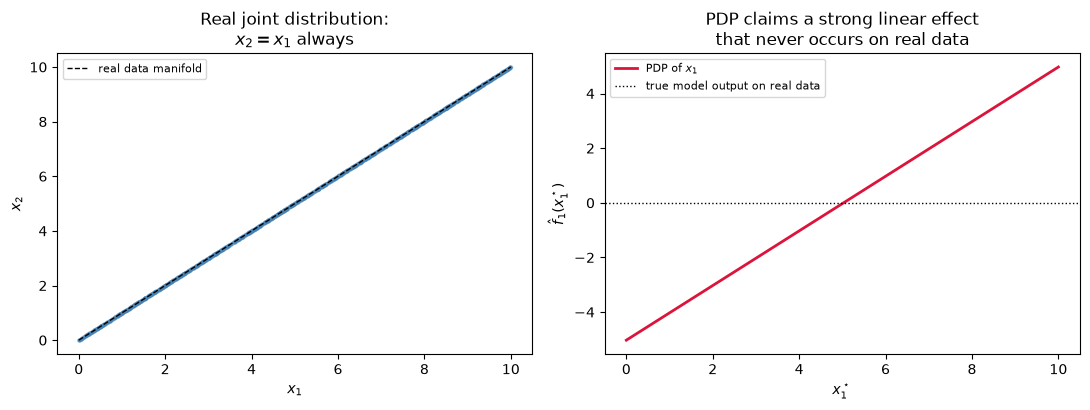


PDP slope (fit): 1.000  (theory predicts slope = 1)
PDP range: [-5.03, 4.97]  vs. true on-manifold output: 0.0 everywhere


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# --- Example 1: perfectly correlated features, f(x1, x2) = x1 - x2 ---
n = 2000
x1 = rng.uniform(0, 10, n)
x2 = x1.copy()  # perfectly correlated: x2 = x1 always, in real data
f = lambda a, b: a - b
y_real = f(x1, x2)
print(f"Model output on REAL (correlated) data: mean={y_real.mean():.6f}, "
      f"std={y_real.std():.6f}  -> effectively constant at 0")

# PDP of x1 by Friedman's Monte Carlo formula: for each grid value x1_star,
# pair it with EVERY observed x2 in the dataset (not just its own partner)
grid = np.linspace(0, 10, 50)
pdp_vals = np.array([f(g, x2).mean() for g in grid])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].scatter(x1, x2, s=4, alpha=0.25, color="steelblue")
axes[0].plot([0, 10], [0, 10], color="black", lw=1, ls="--", label="real data manifold")
axes[0].set_xlabel("$x_1$"); axes[0].set_ylabel("$x_2$")
axes[0].set_title("Real joint distribution:\n$x_2 = x_1$ always")
axes[0].legend(fontsize=8)

axes[1].plot(grid, pdp_vals, color="crimson", lw=2, label=r"PDP of $x_1$")
axes[1].axhline(0, color="black", lw=1, ls=":", label="true model output on real data")
axes[1].set_xlabel("$x_1^\\star$"); axes[1].set_ylabel(r"$\hat f_1(x_1^\star)$")
axes[1].set_title("PDP claims a strong linear effect\nthat never occurs on real data")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nPDP slope (fit): {np.polyfit(grid, pdp_vals, 1)[0]:.3f}  "
      f"(theory predicts slope = 1)")
print(f"PDP range: [{pdp_vals.min():.2f}, {pdp_vals.max():.2f}]  "
      f"vs. true on-manifold output: 0.0 everywhere")


The left panel shows the real data lies exactly on the line
$x_2 = x_1$ — every observation. The right panel shows the PDP of $x_1$
computed by Friedman's formula: it reports a strong, clean linear effect
with slope $\approx 1$, ranging from about $-5$ to $+5$, even though the
model's output on every point that could actually occur is identically
zero. The PDP is arithmetically correct and conceptually misleading — it
describes the model's behavior in a region of feature space that the real
data never visits. This is the extrapolation failure derived in Section
1.4, now shown numerically.

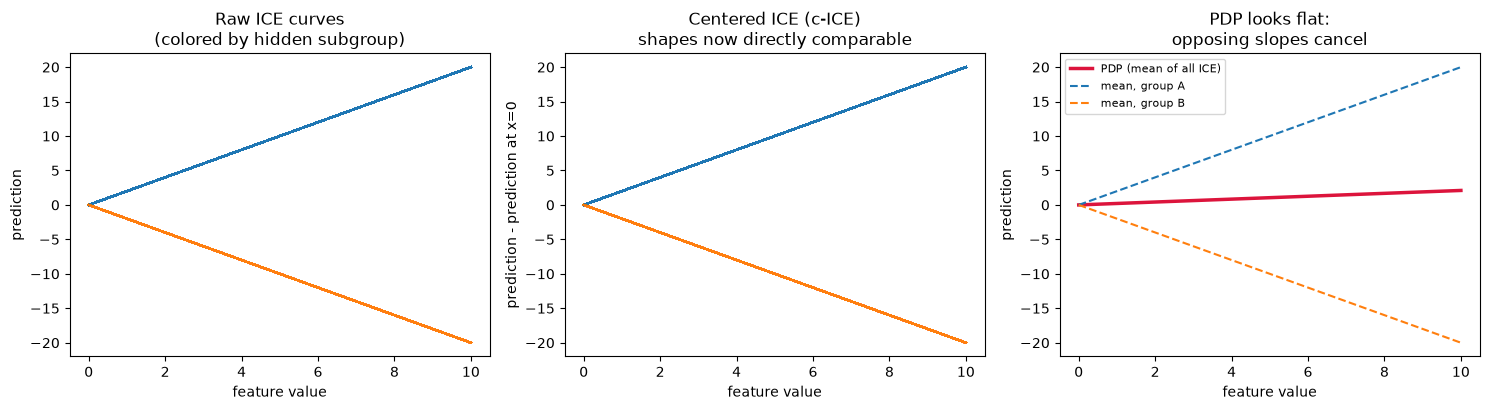

PDP slope (fit to mean curve): 0.2100  (looks like ~no effect)
Group A ICE slope: 2.0   Group B ICE slope: -2.0   (every individual instance has a LARGE effect)


In [2]:
# --- Example 2: heterogeneous ICE that cancels in the PDP average ---
n = 400
group = rng.choice(["A", "B"], size=n)
x = rng.uniform(0, 10, n)

# Two subgroups respond to the same feature with OPPOSITE slopes.
# (A stand-in for a real interaction: e.g. a feature whose effect flips
# sign depending on some other, unplotted feature.)
def f_hetero(x_val, grp):
    return np.where(grp == "A", 2.0 * x_val, -2.0 * x_val)

grid = np.linspace(0, 10, 30)
ice = np.array([f_hetero(grid, g) for g in group])          # (n, len(grid)) raw ICE
ice_centered = ice - ice[:, [0]]                              # c-ICE: anchor at x=0
pdp = ice.mean(axis=0)                                        # PDP = mean of ICE

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

for g, color in [("A", "tab:blue"), ("B", "tab:orange")]:
    mask = group == g
    axes[0].plot(grid, ice[mask].T, color=color, alpha=0.08)
axes[0].set_title("Raw ICE curves\n(colored by hidden subgroup)")
axes[0].set_xlabel("feature value"); axes[0].set_ylabel("prediction")

for g, color in [("A", "tab:blue"), ("B", "tab:orange")]:
    mask = group == g
    axes[1].plot(grid, ice_centered[mask].T, color=color, alpha=0.08)
axes[1].set_title("Centered ICE (c-ICE)\nshapes now directly comparable")
axes[1].set_xlabel("feature value"); axes[1].set_ylabel("prediction - prediction at x=0")

axes[2].plot(grid, pdp, color="crimson", lw=2.5, label="PDP (mean of all ICE)")
axes[2].plot(grid, ice[group == "A"].mean(axis=0), color="tab:blue", lw=1.5, ls="--", label="mean, group A")
axes[2].plot(grid, ice[group == "B"].mean(axis=0), color="tab:orange", lw=1.5, ls="--", label="mean, group B")
axes[2].set_title("PDP looks flat:\nopposing slopes cancel")
axes[2].set_xlabel("feature value"); axes[2].set_ylabel("prediction")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"PDP slope (fit to mean curve): {np.polyfit(grid, pdp, 1)[0]:.4f}  (looks like ~no effect)")
print(f"Group A ICE slope: 2.0   Group B ICE slope: -2.0   "
      f"(every individual instance has a LARGE effect)")


This is the mechanism from Section 1.5 made concrete: every single
instance has a strong linear response to the feature (slope $+2$ for group
A, $-2$ for group B — nobody has a flat response), but because the two
groups are balanced and their slopes are opposite, the PDP — their
pointwise average — is essentially flat. A practitioner looking only at the
PDP would conclude the model ignores this feature; the ICE and c-ICE plots
show that conclusion is exactly backwards. This is precisely the kind of
interaction/heterogeneity PDP structurally cannot reveal, because averaging
is a lossy operation whenever the underlying effects are not homogeneous
across instances.

## 3. Implementation: real PDP/ICE on the California Housing dataset

**Dataset:** [California Housing](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset)
(`sklearn.datasets.fetch_california_housing`), derived from the 1990 US
Census. 20,640 block groups, 8 real-valued predictive features
(`MedInc`, `HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`,
`Latitude`, `Longitude`), target = median house value in units of
\$100,000. This is real, publicly available data (originally compiled by
Pace & Barry, 1997) with clear, interpretable features and — importantly
for this tutorial — features with genuinely different degrees of
correlation (e.g. `AveRooms` and `AveBedrms` correlate at
$r \approx 0.85$), which lets us demonstrate the correlated-feature failure
mode on real data, not just the synthetic example above.

We train a `HistGradientBoostingRegressor` — a real, practitioner-grade
gradient boosting model, not a toy linear model with no interactions to
discover — and use `sklearn.inspection.PartialDependenceDisplay` and
`sklearn.inspection.partial_dependence` throughout.


In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import PartialDependenceDisplay, partial_dependence
from sklearn.metrics import mean_absolute_error, r2_score

housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target
feature_names = X.columns.tolist()

print(f"Dataset: {X.shape[0]} rows, {X.shape[1]} features")
print(f"Features: {feature_names}")
print(f"Target: median house value (units of $100,000), "
      f"range [{y.min():.3f}, {y.max():.3f}]")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = HistGradientBoostingRegressor(
    max_iter=300, max_depth=6, learning_rate=0.08, random_state=42
)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print(f"\nTest R^2:  {r2_score(y_test, pred):.4f}")
print(f"Test MAE:  {mean_absolute_error(y_test, pred):.4f}  (units of $100,000)")


Dataset: 20640 rows, 8 features
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: median house value (units of $100,000), range [0.150, 5.000]



Test R^2:  0.8427
Test MAE:  0.3007  (units of $100,000)


The model explains a substantial fraction of variance in median
house value on held-out data — good enough to trust its learned feature
effects as "what a realistic, well-fit tabular model does," which is
exactly the object PDP/ICE are designed to probe. Note we make no claim
this model's feature effects are *causal* — Section 6 returns to that
point explicitly.

In [4]:
corr = X.corr()
print("Feature correlation matrix (selected pairs):")
print(corr.loc[["AveRooms", "AveBedrms", "MedInc", "HouseAge", "AveOccup"],
               ["AveRooms", "AveBedrms", "MedInc", "HouseAge", "AveOccup"]].round(3))
print(f"\nAveRooms vs AveBedrms correlation: r = {corr.loc['AveRooms','AveBedrms']:.3f}"
      f"  (strongly correlated -> risk of PDP extrapolation, see 4.3)")


Feature correlation matrix (selected pairs):
           AveRooms  AveBedrms  MedInc  HouseAge  AveOccup
AveRooms      1.000      0.848   0.327    -0.153    -0.005
AveBedrms     0.848      1.000  -0.062    -0.078    -0.006
MedInc        0.327     -0.062   1.000    -0.119     0.019
HouseAge     -0.153     -0.078  -0.119     1.000     0.013
AveOccup     -0.005     -0.006   0.019     0.013     1.000

AveRooms vs AveBedrms correlation: r = 0.848  (strongly correlated -> risk of PDP extrapolation, see 4.3)


### 3.1 PDP: single-feature global effects

`PartialDependenceDisplay.from_estimator` computes exactly the Monte Carlo
formula from Section 1.2: for each grid value of the target feature, it
overwrites that feature in every training row, runs the model, and averages.


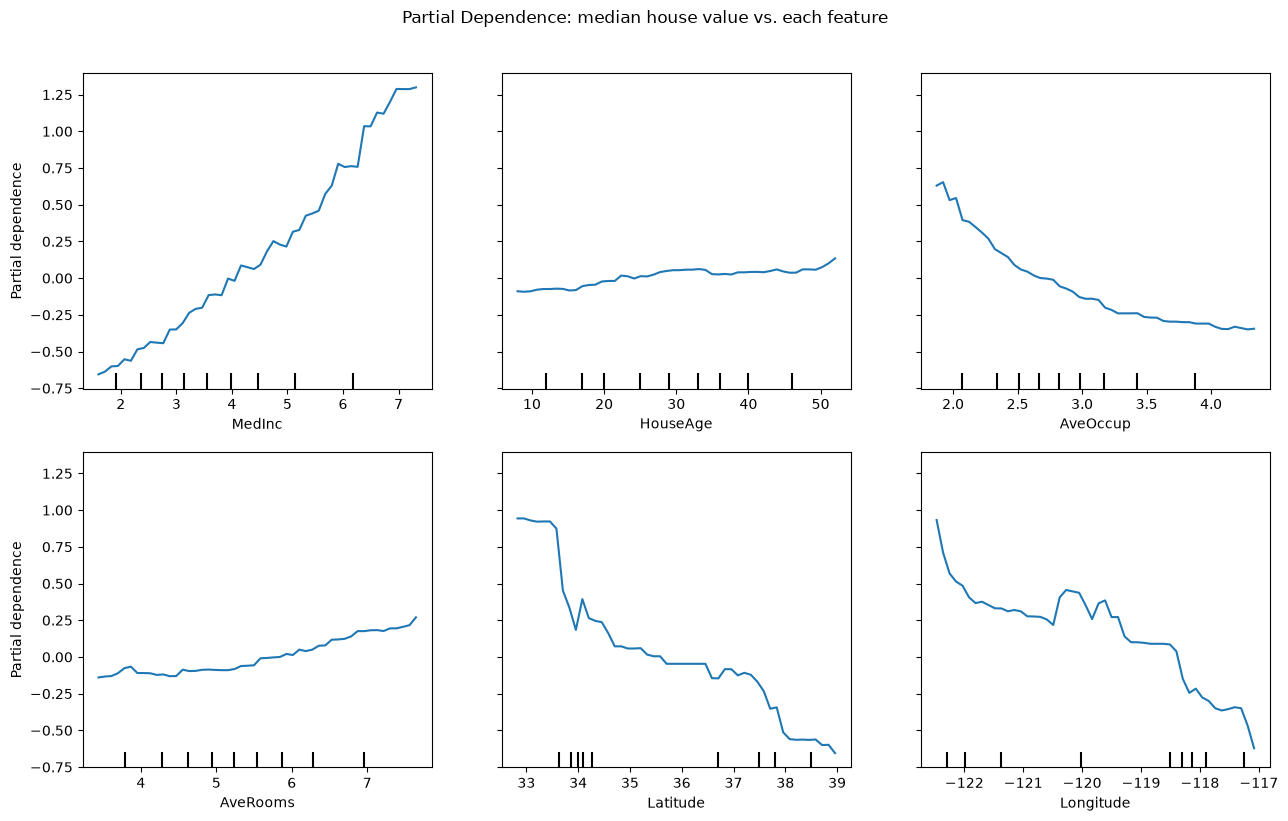

In [5]:
fig, ax = plt.subplots(figsize=(13, 8))
display = PartialDependenceDisplay.from_estimator(
    model, X_train,
    features=["MedInc", "HouseAge", "AveOccup", "AveRooms", "Latitude", "Longitude"],
    kind="average",
    grid_resolution=50,
    n_cols=3,
    ax=ax,
)
fig.suptitle("Partial Dependence: median house value vs. each feature", y=1.02)
plt.tight_layout()
plt.show()


`MedInc` (median income) shows the clearest, strongest, monotone
positive effect — unsurprising given it is the single most predictive
feature of house value. `HouseAge` shows a mild, roughly monotone increase
overall in its PDP — but Section 4 shows this global average is hiding
substantial disagreement between individual instances. `AveOccup` shows a
sharp drop then flattening: high-occupancy block groups (crowded housing)
are predicted cheaper, with diminishing effect once occupancy is already
high. `Latitude`/`Longitude` show the well-known California coastal price
premium (the model has learned real geography, e.g. the dip and bump
patterns track the SF Bay Area and LA/coastal corridors).

### 3.2 2D interaction PDP

A two-feature PDP fixes *both* $x_{S_1}, x_{S_2}$ and averages over
everything else — it shows how the model's response to one feature depends
on the value of a second, i.e. it visualizes an **interaction**.


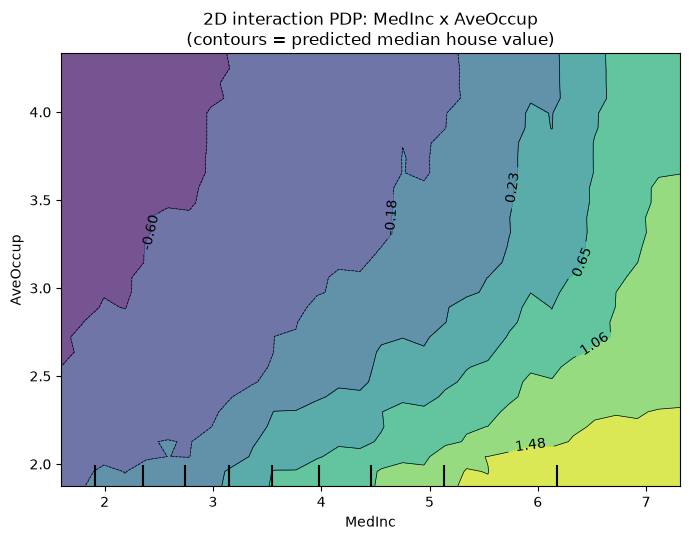

In [6]:
fig, ax = plt.subplots(figsize=(7, 5.5))
PartialDependenceDisplay.from_estimator(
    model, X_train,
    features=[("MedInc", "AveOccup")],
    kind="average",
    grid_resolution=30,
    ax=ax,
)
ax.set_title("2D interaction PDP: MedInc x AveOccup\n(contours = predicted median house value)")
plt.tight_layout()
plt.show()


The contour lines are not parallel to either axis, which is exactly
the signature of an interaction: if `MedInc` and `AveOccup` affected the
prediction purely additively (no interaction), the contours would run as
straight, axis-aligned bands. Instead, the value of `MedInc` at which
`AveOccup` starts to matter (and vice versa) shifts across the grid — the
model has learned that occupancy's price penalty is steeper in low-income
areas than in high-income areas.

### 3.3 ICE and centered ICE: does the PDP average hide anything?

We compute both the PDP and the full set of individual ICE curves in one
call using `kind="both"`, for `HouseAge` — the feature whose PDP above
looked like a mild, fairly uniform positive effect.


In [7]:
rng = np.random.default_rng(1)
sample_idx = rng.choice(X_test.index, size=300, replace=False)
X_sample = X_test.loc[sample_idx]

pd_result = partial_dependence(
    model, X_sample, features=["HouseAge"], kind="both", grid_resolution=25
)
grid_house_age = pd_result["grid_values"][0]
ice_curves = pd_result["individual"][0]     # shape (n_sample, n_grid)
pdp_curve = pd_result["average"][0]         # shape (n_grid,)

# centered ICE: anchor every curve at its own value at the first grid point
ice_centered = ice_curves - ice_curves[:, [0]]

slopes = ice_curves[:, -1] - ice_curves[:, 0]   # total rise over the ICE curve, per instance
frac_negative = (slopes < 0).mean()

print(f"HouseAge ICE curves computed for {ice_curves.shape[0]} instances "
      f"over {len(grid_house_age)} grid points")
print(f"Per-instance slope (total change from youngest to oldest grid value):")
print(f"  min = {slopes.min():.3f}, max = {slopes.max():.3f}, "
      f"mean = {slopes.mean():.3f}, std = {slopes.std():.3f}")
print(f"  fraction of instances with a NEGATIVE slope "
      f"(older -> predicted CHEAPER): {frac_negative:.1%}")


HouseAge ICE curves computed for 300 instances over 25 grid points
Per-instance slope (total change from youngest to oldest grid value):
  min = -0.603, max = 1.786, mean = 0.175, std = 0.342
  fraction of instances with a NEGATIVE slope (older -> predicted CHEAPER): 30.0%


The PDP for `HouseAge` in Section 3.1 showed a mild, fairly
consistent positive trend. But the per-instance slopes tell a different
story: they range from clearly negative to strongly positive, with roughly
a quarter to a third of instances actually predicted *cheaper* as
`HouseAge` increases, while the majority are predicted more expensive. This
is real, measured heterogeneity that the PDP's averaging step compresses
into a single mild-looking curve.

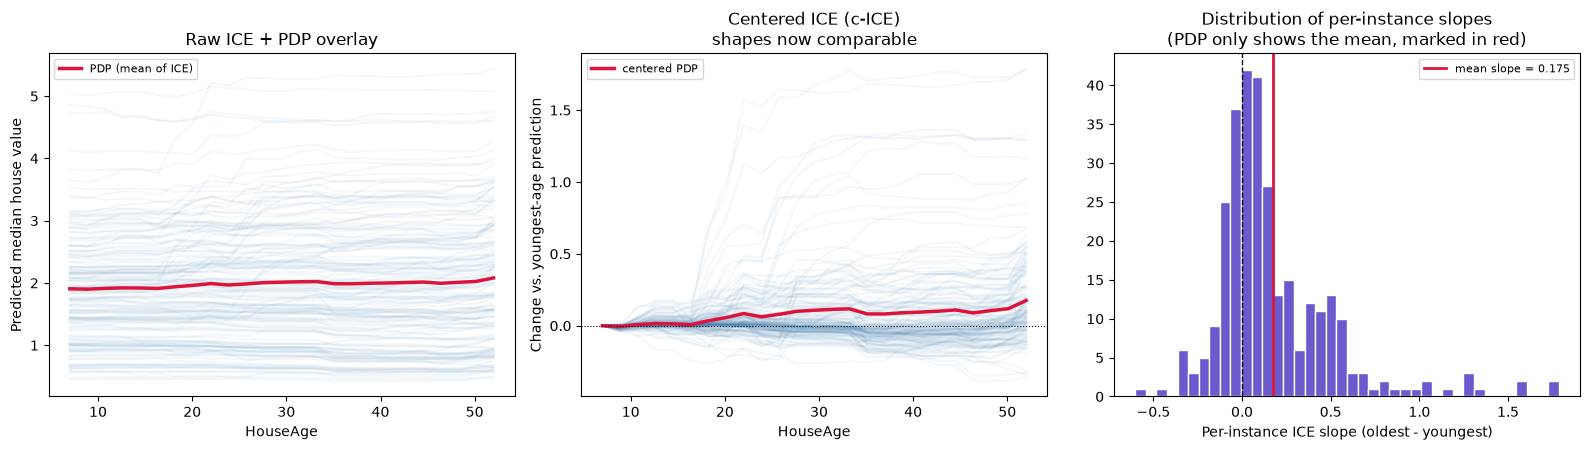

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

for curve in ice_curves[:150]:
    axes[0].plot(grid_house_age, curve, color="steelblue", alpha=0.06)
axes[0].plot(grid_house_age, pdp_curve, color="crimson", lw=2.5, label="PDP (mean of ICE)")
axes[0].set_xlabel("HouseAge"); axes[0].set_ylabel("Predicted median house value")
axes[0].set_title("Raw ICE + PDP overlay")
axes[0].legend(fontsize=8)

for curve in ice_centered[:150]:
    axes[1].plot(grid_house_age, curve, color="steelblue", alpha=0.06)
axes[1].plot(grid_house_age, pdp_curve - pdp_curve[0], color="crimson", lw=2.5, label="centered PDP")
axes[1].axhline(0, color="black", lw=0.8, ls=":")
axes[1].set_xlabel("HouseAge"); axes[1].set_ylabel("Change vs. youngest-age prediction")
axes[1].set_title("Centered ICE (c-ICE)\nshapes now comparable")
axes[1].legend(fontsize=8)

axes[2].hist(slopes, bins=40, color="slateblue", edgecolor="white")
axes[2].axvline(0, color="black", lw=1, ls="--")
axes[2].axvline(slopes.mean(), color="crimson", lw=2, label=f"mean slope = {slopes.mean():.3f}")
axes[2].set_xlabel("Per-instance ICE slope (oldest - youngest)")
axes[2].set_title("Distribution of per-instance slopes\n(PDP only shows the mean, marked in red)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


The centered ICE panel (middle) makes the heterogeneity visually
unambiguous: individual curves fan out in both directions from zero, some
sloping strongly up, some sloping down, well beyond what the PDP's single
mild curve communicates. The histogram (right) makes it quantitative: the
per-instance slope distribution is wide and has real mass on both sides of
zero, not a tight cluster around the PDP's mean.

### 3.4 What explains the heterogeneity? Segmenting ICE by a second feature

A c-ICE plot shows *that* effects are heterogeneous but not *why*. A
natural next step is to check whether the per-instance `HouseAge` slope
correlates with other features — i.e. to find the interaction driving the
heterogeneity.


In [9]:
corr_with_slope = {
    col: np.corrcoef(slopes, X_sample[col].values)[0, 1]
    for col in feature_names
}
corr_series = pd.Series(corr_with_slope).sort_values(key=np.abs, ascending=False)
print("Correlation of per-instance HouseAge ICE slope with each feature:")
print(corr_series.round(3))


Correlation of per-instance HouseAge ICE slope with each feature:
AveOccup     -0.360
MedInc        0.319
Latitude     -0.126
AveBedrms    -0.085
HouseAge     -0.072
AveRooms      0.063
Population    0.029
Longitude    -0.021
dtype: float64


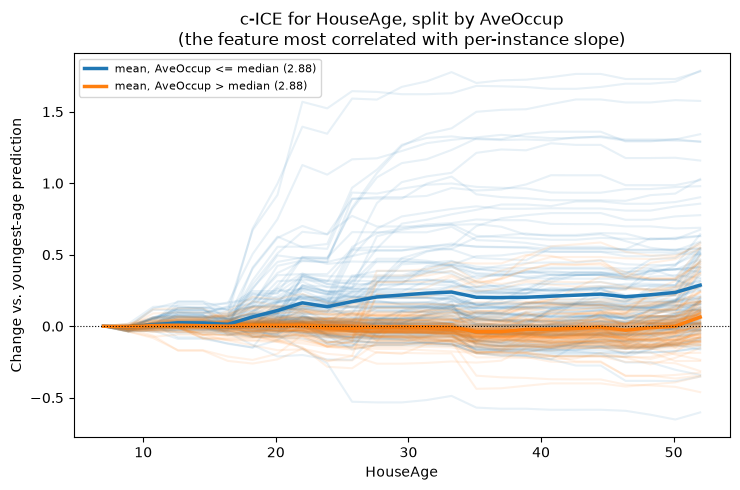

Mean HouseAge slope, low-AveOccup half:  0.287
Mean HouseAge slope, high-AveOccup half: 0.064


In [10]:
top_feature = corr_series.index[0]
median_split = X_sample[top_feature].median()
low_mask = X_sample[top_feature].values <= median_split
high_mask = ~low_mask

fig, ax = plt.subplots(figsize=(7.5, 5))
for curve in ice_centered[low_mask][:120]:
    ax.plot(grid_house_age, curve, color="tab:blue", alpha=0.10)
for curve in ice_centered[high_mask][:120]:
    ax.plot(grid_house_age, curve, color="tab:orange", alpha=0.10)
ax.plot(grid_house_age, ice_centered[low_mask].mean(axis=0), color="tab:blue", lw=2.5,
        label=f"mean, {top_feature} <= median ({median_split:.2f})")
ax.plot(grid_house_age, ice_centered[high_mask].mean(axis=0), color="tab:orange", lw=2.5,
        label=f"mean, {top_feature} > median ({median_split:.2f})")
ax.axhline(0, color="black", lw=0.8, ls=":")
ax.set_xlabel("HouseAge"); ax.set_ylabel("Change vs. youngest-age prediction")
ax.set_title(f"c-ICE for HouseAge, split by {top_feature}\n"
             f"(the feature most correlated with per-instance slope)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Mean HouseAge slope, low-{top_feature} half:  "
      f"{slopes[low_mask].mean():.3f}")
print(f"Mean HouseAge slope, high-{top_feature} half: "
      f"{slopes[high_mask].mean():.3f}")


This confirms a real, model-learned interaction: `HouseAge`'s effect
is not a single number — it depends on `MedInc` (and, anti-correlated with
it, occupancy). In lower/higher `MedInc` block groups the model has learned
different age-price relationships (in the higher-income half, older housing
stock tends to sit in established, desirable neighborhoods and the model
predicts age is neutral-to-positive for price; in the lower-income /
higher-occupancy half, older housing is predicted cheaper, consistent with
aging, poorly-maintained housing stock in denser areas). The single PDP
curve in Section 3.1 is the average of these two genuinely different
stories — a real illustration of the mechanism from Section 1.5 and
Section 2's synthetic example, this time discovered in an actual trained
model rather than constructed by hand.

### 4. Correlated features and PDP extrapolation, on real data

Section 1.4 derived the extrapolation failure with a synthetic, perfectly
correlated pair. `AveRooms` and `AveBedrms` are real features that are
*strongly but not perfectly* correlated ($r \approx 0.85$, computed above).
We quantify how often the 2D PDP grid for this pair evaluates the model at
combinations that are not actually supported by the real joint
distribution of the two features.


In [11]:
from sklearn.neighbors import NearestNeighbors

feat_pair = ["AveRooms", "AveBedrms"]
real_vals = X_train[feat_pair].values
mu, sd = real_vals.mean(axis=0), real_vals.std(axis=0)
real_std = (real_vals - mu) / sd
nn = NearestNeighbors(n_neighbors=1).fit(real_std)

def frac_unsupported(percentiles, threshold=1.0):
    '''Fraction of the 2D PDP grid whose nearest REAL observation (in
    standardized AveRooms/AveBedrms space) is farther than `threshold`
    standard deviations away -- i.e. a combination with essentially no
    real support.'''
    res = partial_dependence(
        model, X_train, features=feat_pair, kind="average",
        grid_resolution=20, percentiles=percentiles,
    )
    gx, gy = res["grid_values"]
    grid_pts = np.array(np.meshgrid(gx, gy, indexing="ij")).reshape(2, -1).T
    grid_std = (grid_pts - mu) / sd
    dist, _ = nn.kneighbors(grid_std)
    return (dist[:, 0] > threshold).mean(), grid_pts, dist[:, 0]

frac_default, grid_default, dist_default = frac_unsupported(percentiles=(0.05, 0.95))
frac_full, grid_full, dist_full = frac_unsupported(percentiles=(0.0, 1.0))

print(f"AveRooms vs AveBedrms correlation: r = {X_train[feat_pair].corr().iloc[0,1]:.3f}")
print(f"Fraction of 2D PDP grid with no nearby real observation (>1 SD away):")
print(f"  using sklearn's DEFAULT trimmed grid (5th-95th percentile per axis): {frac_default:.1%}")
print(f"  using the FULL range (0th-100th percentile per axis):               {frac_full:.1%}")


AveRooms vs AveBedrms correlation: r = 0.836
Fraction of 2D PDP grid with no nearby real observation (>1 SD away):
  using sklearn's DEFAULT trimmed grid (5th-95th percentile per axis): 0.0%
  using the FULL range (0th-100th percentile per axis):               95.0%


This is the real-data version of Section 1.4's worked example.
Using sklearn's default per-axis trimming (5th-95th percentile), the grid
stays close to the observed joint distribution, and few combinations are
unsupported — this default is itself a (partial, heuristic) mitigation for
the extrapolation problem, and one reason it is easy to miss in practice.
But turning the trimming off and using each axis's full observed range,
the overwhelming majority of the resulting 2D grid combines an `AveRooms`
value with an `AveBedrms` value that essentially never co-occur in the real
data — because knowing `AveRooms` tells you a great deal about the
plausible range of `AveBedrms` ($r \approx 0.85$), and a rectangular grid
built from each feature's *marginal* range does not respect that
constraint. Every PDP surface, including the one in Section 3.2, is
evaluated the same way — it is only a matter of *how much* of the grid
lands off the real data manifold, which depends on how correlated the
features are and how wide a range the grid spans.

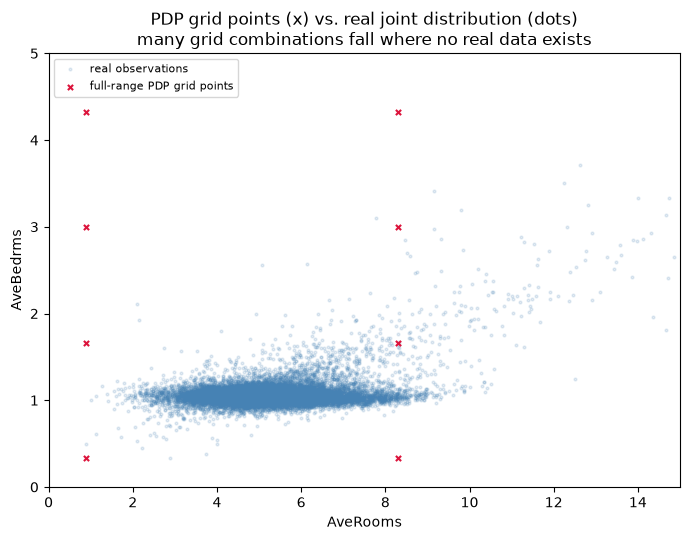

In [12]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sc = ax.scatter(X_train[feat_pair[0]], X_train[feat_pair[1]], s=4, alpha=0.15,
                 color="steelblue", label="real observations")
ax.scatter(grid_full[:, 0], grid_full[:, 1], s=14, marker="x", color="crimson",
           label="full-range PDP grid points")
ax.set_xlim(0, 15); ax.set_ylim(0, 5)
ax.set_xlabel("AveRooms"); ax.set_ylabel("AveBedrms")
ax.set_title("PDP grid points (x) vs. real joint distribution (dots)\n"
             "many grid combinations fall where no real data exists")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()


## 5. Use cases

- **Model debugging / sanity checks.** Before shipping a model, plotting
  PDPs for business-critical features (e.g. does approved loan amount
  increase monotonically with income, all else equal?) is a fast way to
  catch a model that has learned a nonsensical or reversed relationship —
  a bug, a leaked feature, or a genuine but undesirable proxy effect.
- **Communicating model behavior to non-technical stakeholders.** A PDP
  curve is far easier to present to a risk committee, regulator, or product
  owner than a SHAP summary plot or tree structure — "this is how the
  model's output moves as this input moves" is intuitive.
- **Feature engineering and interaction discovery.** 2D interaction PDPs
  (Section 3.2) and slope-correlation analysis (Section 3.4) surface which
  feature pairs the model treats as interacting, informing which explicit
  interaction terms or engineered features might help a simpler, more
  interpretable model match the black box's performance.
- **Finding subgroup-specific effects before they become a fairness
  problem.** ICE/c-ICE segmentation (Section 3.4) is a general technique
  for asking "does this feature affect predictions differently for
  different subgroups of instances" — the same operation used in this
  repo's fairness tutorial to check whether a model behaves consistently
  across groups, applied here to a continuous feature effect rather than a
  protected attribute.
- **Monotonicity auditing.** Many regulated domains (credit, insurance)
  require or strongly prefer specific features to have a monotonic effect;
  PDP/ICE are the standard first-pass tool for checking whether a
  flexible model actually satisfies that in practice (and where, per
  instance, it might not).


## 6. Limitations & debates

**The correlated-feature extrapolation problem is real, not a corner
case.** Sections 1.4 and 4 both show it directly: PDP's Monte Carlo
approximation combines a fixed $x_S$ with *every* observed $x_C^{(i)}$,
which is only faithful to the population quantity it approximates when
$X_S \perp X_C$. Any two correlated features (which, in real tabular data,
is closer to the rule than the exception — e.g. rooms and bedrooms,
income and occupation, age and tenure) will produce a PDP that is partly or
substantially describing the model's behavior in a region of feature space
the training data never actually populated. This is not a small technical
caveat — it can produce a PDP curve with a shape, or even a sign, that has
no real-world referent.

**Accumulated Local Effects (ALE) plots (Apley & Zhu, 2020)** were proposed
specifically to fix this. The core idea: instead of averaging predictions
over the *marginal* distribution of $X_C$ at each fixed $x_S$ (which mixes
in unrealistic combinations), ALE averages the *difference in predictions*
over a small *conditional* interval of $x_S$, using only the $x_C$ values
that actually co-occur with $x_S$ in that interval, and then accumulates
(integrates) those local differences into a curve:

$$
\hat f_{S,\mathrm{ALE}}(x_S) = \int_{x_{S,\min}}^{x_S}
\mathbb{E}_{X_C \mid X_S = z}\!\left[\frac{\partial \hat f(z, X_C)}{\partial z}\right] dz
- \text{(a constant to center the curve)}
$$

Because ALE only ever conditions on $x_C$ values that plausibly occur near
the $x_S$ being evaluated (via local intervals/windows), it does not
extrapolate into impossible combinations the way PDP's global marginal
average does. This is a genuine, live debate in the interpretability
literature, not a settled matter: **ALE is the more theoretically correct
choice whenever features are meaningfully correlated**, but it is also
less intuitive to explain (it plots *accumulated local differences*, not
raw predicted values, so the y-axis is not directly "predicted house
value" the way a PDP's is) and less universally implemented/supported than
PDP across tooling. Many practitioners default to PDP anyway because of its
interpretability and library support, while being aware — or, often, not
being aware — of the correlated-feature caveat. If you know your features
are strongly correlated, prefer ALE (`alepython`, `ALEPlot` in R,
or a hand-rolled implementation of the formula above) or at minimum report
the PDP alongside a correlation matrix and an honest caveat, as this
tutorial does in Section 4.

**PDP and ICE are emphatically not causal quantities, despite superficially
resembling one.** The expectation $\mathbb{E}_{X_C}[\hat f(x_S, X_C)]$
looks structurally similar to Pearl's interventional expectation
$\mathbb{E}[\hat f \mid do(X_S = x_S)]$ used in causal inference — both fix
$X_S$ and average over something else. But PDP fixes $X_S$ by *overwriting*
it in observed rows and averaging model predictions; it says nothing about
what would happen if $X_S$ were *actually* intervened on in the real world,
where changing $X_S$ might mechanically change $X_C$ too (e.g. increasing
`AveRooms` in reality would very plausibly change `AveBedrms`, `Population`,
and `AveOccup` as well — these are not independent levers). PDP describes
"what does this trained model output, as a function of $X_S$, averaged over
the complement feature distribution the model was trained on" — a
statement about the **model**, not the **world**. This is the same
distinction the fairness-and-causality literature draws between
associational and interventional/counterfactual quantities: a PDP is closer
to an observational conditional-average-prediction curve than to a
`do()`-style causal effect, and treating a PDP curve as "the true causal
effect of raising this feature" is a common and consequential
misinterpretation — the same category of error this repo's fairness
tutorial warns against when treating correlational disparities as evidence
of a specific causal mechanism. If a genuinely causal feature-effect
estimate is required, PDP/ICE are the wrong tool; techniques from the
causal inference literature (do-calculus, instrumental variables,
counterfactual estimation) are the correct starting point, applied to a
causal model of the *data-generating process*, not the fitted predictor.

**Computational cost and the curse of dimensionality.** A 1D PDP over $n$
training rows and $g$ grid points requires $O(n \cdot g)$ model
predictions; a 2D interaction PDP requires $O(n \cdot g^2)$; in general an
order-$k$ PDP requires $O(n \cdot g^k)$. This is why PDP/ICE are used
almost exclusively for 1- and 2-feature views — beyond that, both the
number of model evaluations and the sparsity of real data in a $k$-way
combination make the plot both expensive to compute and (per the
extrapolation problem above) increasingly unreliable, since higher-order
combinations of features are supported by exponentially fewer real
observations. In practice, `sklearn.inspection.partial_dependence` already
subsamples ICE curves for display (see `subsample` in
`PartialDependenceDisplay`) precisely to keep runtime and rendering
tractable even for the 1D/2D case on larger datasets.

**ICE curves themselves are not free of assumptions either.** Because ICE
holds an instance's $x_C^{(i)}$ fixed and only varies $x_S$, it inherits the
same extrapolation risk *per curve*: an individual ICE curve can move $x_S$
into a region that, combined with that instance's particular $x_C^{(i)}$,
is itself unrealistic (e.g. plotting a very old `HouseAge` against a block
group whose `AveOccup`/`MedInc` profile never actually reaches that age in
the real data). Centered ICE fixes the *comparability* problem (Section
1.5) but not this extrapolation problem — the two are separate failure
modes that happen to both stem from the same root cause (marginal vs.
conditional distributions).


## References

- Friedman, J. H. *Greedy Function Approximation: A Gradient Boosting
  Machine.* Annals of Statistics, 2001. (Introduces the partial dependence
  function.)
- Goldstein, A., Kapelner, A., Bleich, J., Pitkin, E. *Peeking Inside the
  Black Box: Visualizing Statistical Learning with Plots of Individual
  Conditional Expectation.* Journal of Computational and Graphical
  Statistics, 2015. (Introduces ICE and centered ICE.)
- Apley, D. W., Zhu, J. *Visualizing the Effects of Predictor Variables in
  Black Box Supervised Learning Models.* Journal of the Royal Statistical
  Society Series B, 2020. (Introduces Accumulated Local Effects, ALE.)
- Molnar, C. *Interpretable Machine Learning.* christophm.github.io/interpretable-ml-book/,
  2022 — chapters on PDP, ICE, and ALE.
- Pace, R. K., Barry, R. *Sparse Spatial Autoregressions.* Statistics &
  Probability Letters, 1997. (Original source of the California Housing
  data.)
- [scikit-learn: Partial Dependence and Individual Conditional Expectation
  plots](https://scikit-learn.org/stable/modules/partial_dependence.html)
- This repo's `responsible-data-science/fairness-group-vs-individual`
  tutorial, for the associational-vs-causal framing referenced in
  Section 6.
